In [1]:
import powerlaw
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from collections import Counter
# import numpy as np
# import seaborn as sns
import xgi
# from matplotlib import cm
# from draw import *
notebook_dir = os.getcwd()  # This gets the current working directory in Jupyter
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
from sod import *
from sod.simpliciality import edit_simpliciality
# from sod.simpliciality import edge_rewiring
from edge_rewiring import edge_rewiring_alg
from edge_rewiring import edge_rewiring_exper
from edge_rewiring import power_law

[0, 2, 3, 7]
[3, 7]
[0, 2, 7]
[1, 4, 5, 6]
[1, 4, 5]
[1, 4]
[1, 6]
sum: 4
Edit simpliciality for: 0.3181818181818182


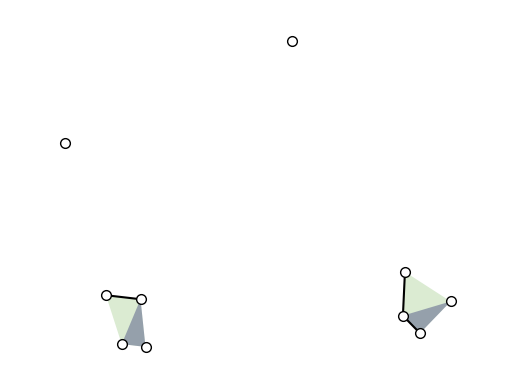

In [2]:
from edge_rewiring import model_generation
import matplotlib.pyplot as plt
import math

# Generate hypergraph
# H = xgi.load_xgi_data(edge_rewiring_exper.datasets[0], max_order=11)
H = model_generation.model_generation_es(es=.3, approx_num_C=16, num_max_hyperedge=2,num_node=10, min_size=2, max_size=None)
for edge in H.edges.members():
    print(list(edge))
sum = 0
for i in range(2, 3 + 1):
    sum += math.comb(i, 2)
print(f"sum: {sum}")


xgi.draw(H)
curr_es = edit_simpliciality(H, min_size=2)
print(f"Edit simpliciality for: {curr_es}")


In [3]:
H = model_generation.model_generation_sf(sf=0.3, approx_num_E=1000, num_node=1000, min_size=2, max_size=None)
for edge in H.edges.members():
    print(list(edge))

[715, 903]
[715, 142]
[715, 615]
[142, 903]
[615, 903]
[142, 615]
[715, 142, 903]
[715, 615, 903]
[715, 142, 615]
[615, 142, 903]
[715, 615, 142, 903]
[675, 533, 140, 222, 479]
[914, 332]
[196, 646, 822, 440, 585]
[101, 597]
[130, 818, 883, 521, 714, 494]
[177, 946, 308, 648, 797]
[129, 546, 83, 340, 959]
[595, 932, 329, 589, 521]
[59, 365]
[59, 380]
[819, 59]
[298, 59]
[380, 365]
[298, 365]
[705, 365]
[819, 380]
[298, 380]
[705, 380]
[298, 819]
[705, 819]
[705, 298]
[59, 380, 365]
[819, 59, 365]
[705, 59, 365]
[819, 59, 380]
[298, 59, 380]
[705, 59, 380]
[819, 298, 59]
[819, 59, 705]
[819, 380, 365]
[705, 380, 365]
[298, 819, 365]
[705, 819, 365]
[705, 298, 365]
[298, 819, 380]
[705, 819, 380]
[705, 298, 380]
[705, 298, 819]
[819, 59, 380, 365]
[298, 59, 380, 365]
[819, 298, 59, 365]
[819, 59, 705, 365]
[705, 298, 59, 365]
[705, 298, 59, 380]
[819, 298, 59, 705]
[298, 819, 380, 365]
[705, 819, 380, 365]
[705, 298, 380, 365]
[705, 298, 819, 365]
[705, 298, 819, 380]
[819, 298, 59, 380,

Hypergraph named email-Enron with 148 nodes and 10885 hyperedges
[3, 5, 6, 6, 6, 10, 12, 12, 13, 14, 14, 15, 15, 16, 18, 19, 19, 20, 20, 20, 21, 22, 22, 23, 24, 25, 25, 29, 30, 32, 32, 33, 34, 34, 35, 38, 38, 40, 43, 46, 47, 48, 48, 49, 49, 50, 51, 56, 57, 58, 58, 62, 67, 67, 69, 69, 70, 70, 70, 72, 75, 78, 83, 83, 87, 89, 93, 94, 97, 104, 108, 111, 111, 117, 117, 119, 122, 123, 126, 128, 130, 131, 134, 137, 138, 140, 142, 150, 153, 154, 157, 157, 165, 167, 171, 172, 174, 175, 192, 197, 202, 208, 209, 209, 226, 237, 238, 240, 257, 260, 272, 281, 301, 308, 309, 317, 322, 328, 338, 354, 357, 362, 368, 377, 389, 394, 399, 415, 419, 428, 466, 494, 501, 502, 510, 627, 754, 880, 906, 967, 1097, 1282, 1327]
Calculating best minimal value for power law fit
Power-law alpha: 3.0909
xmin: 301.0
Sigma: 0.3755
Loglikelihood ratio R: 1.1319
p-value: 0.4750


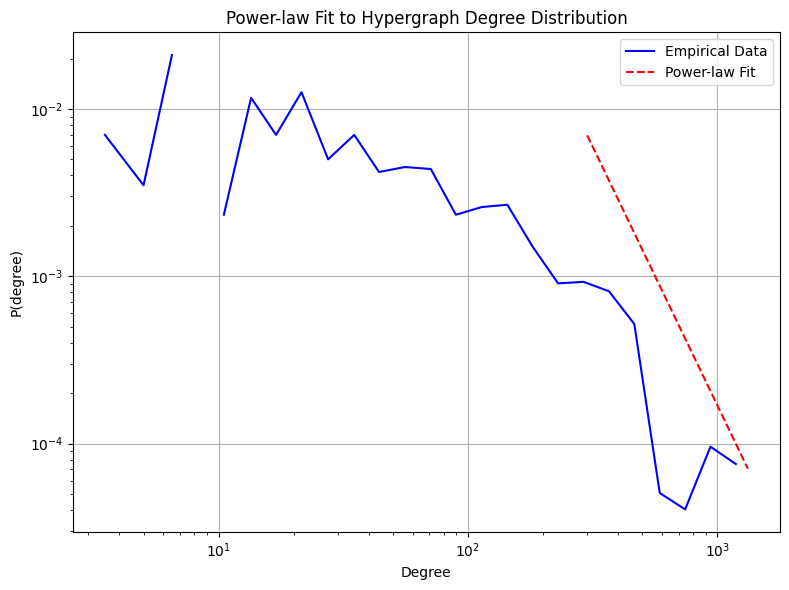

In [4]:
from edge_rewiring import edge_rewiring_alg

H = xgi.load_xgi_data(edge_rewiring_exper.datasets[3])
# es = edit_simpliciality(H, min_size=2)
# print(f"Edit simpliciality: {es}")

print(H)
degree_dict = H.degree()
#print(degree_dict)
degree_list = list(degree_dict.values())
#print(degree_list)
sorted_degrees = sorted(degree_dict.values())
filtered_degrees = [d for d in sorted_degrees if d > 0]
print(filtered_degrees)

fit = powerlaw.Fit(filtered_degrees)
print(f"Power-law alpha: {fit.power_law.alpha:.4f}")
print(f"xmin: {fit.xmin}")
print(f"Sigma: {fit.power_law.sigma:.4f}")

R, p = fit.distribution_compare('power_law', 'exponential')
print(f"Loglikelihood ratio R: {R:.4f}")
print(f"p-value: {p:.4f}")

plt.figure(figsize=(8, 6))
powerlaw.plot_pdf(filtered_degrees, color='b', label='Empirical Data')
fit.power_law.plot_pdf(color='r', linestyle='--', label='Power-law Fit')
plt.xlabel("Degree")
plt.ylabel("P(degree)")
plt.title("Power-law Fit to Hypergraph Degree Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Hypergraph named congress-bills with 1718 nodes and 282049 hyperedges
Calculating best minimal value for power law fit
  R = 0.1380, p = 0.7031


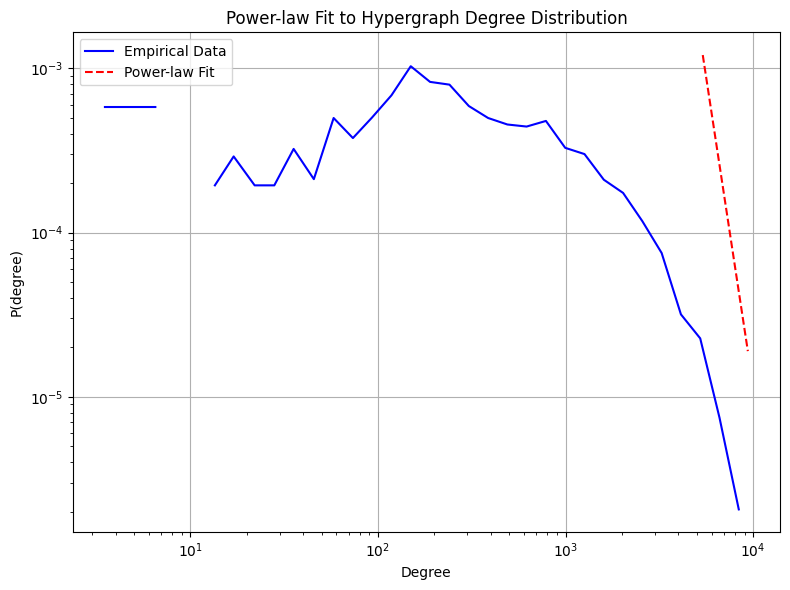

True
Follows power-law:


In [5]:
from edge_rewiring import power_law
import xgi
from edge_rewiring import edge_rewiring_exper
from edge_rewiring import power_law

H = xgi.load_xgi_data(edge_rewiring_exper.datasets[8])
print(H)
# H.cleanup(singletons=True)

result = power_law.has_powerlaw(H, p_value=0.10)
print(result)

print("Follows power-law:" if result else "Does not follow power-law.")


Unnamed Hypergraph with 400 nodes and 511 hyperedges
Calculating best minimal value for power law fit
  R = 4.3704, p = 0.0609


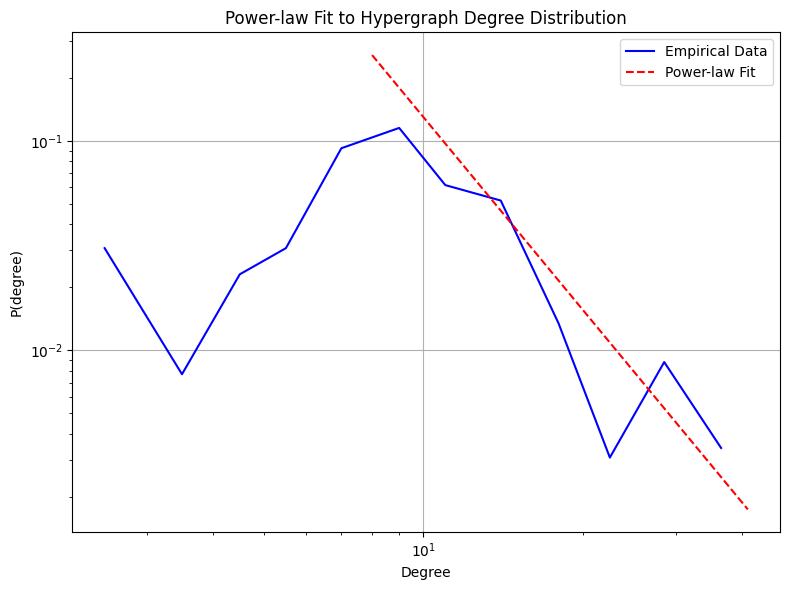

False
Does not follow power-law.


In [6]:
H = model_generation.model_generation_es(es=.5, approx_num_C=700, num_max_hyperedge=30, num_node=400, min_size=2, max_size=10)
print(H)
# H.cleanup(singletons=True)

result = power_law.has_powerlaw(H, p_value=0.10)
print(result)

print("Follows power-law:" if result else "Does not follow power-law.")


Calculating best minimal value for power law fit
  R = 53.8971, p = 0.0000


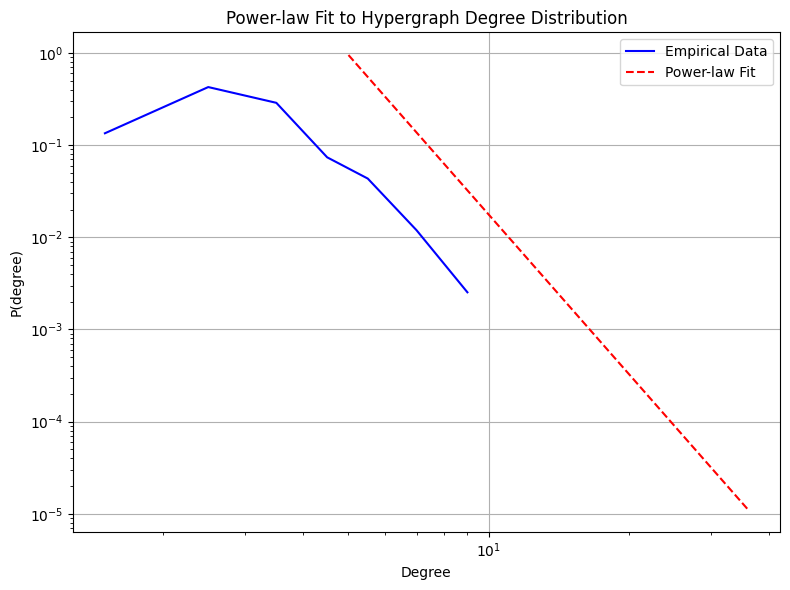

Trial 1: ❌ Does NOT follow power-law
Calculating best minimal value for power law fit
  R = 22.3438, p = 0.0000


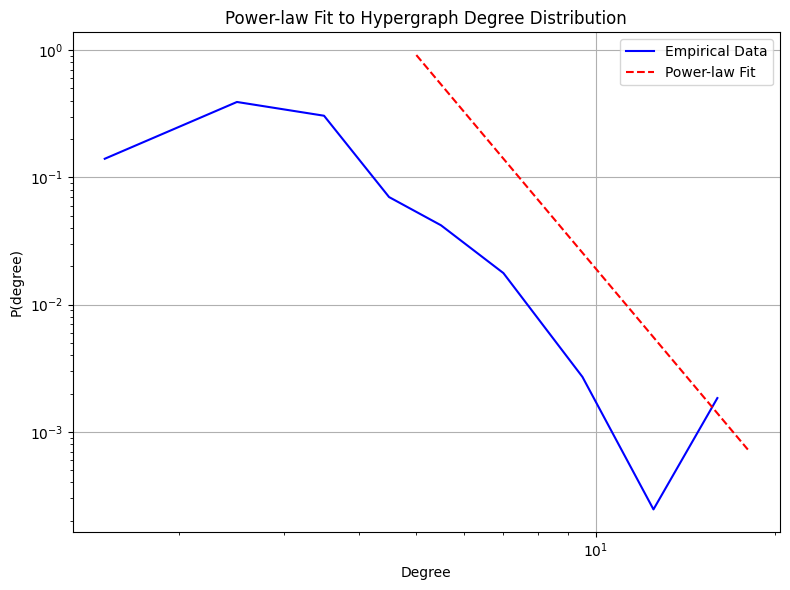

Trial 2: ❌ Does NOT follow power-law
Calculating best minimal value for power law fit
  R = 9.0470, p = 0.0000


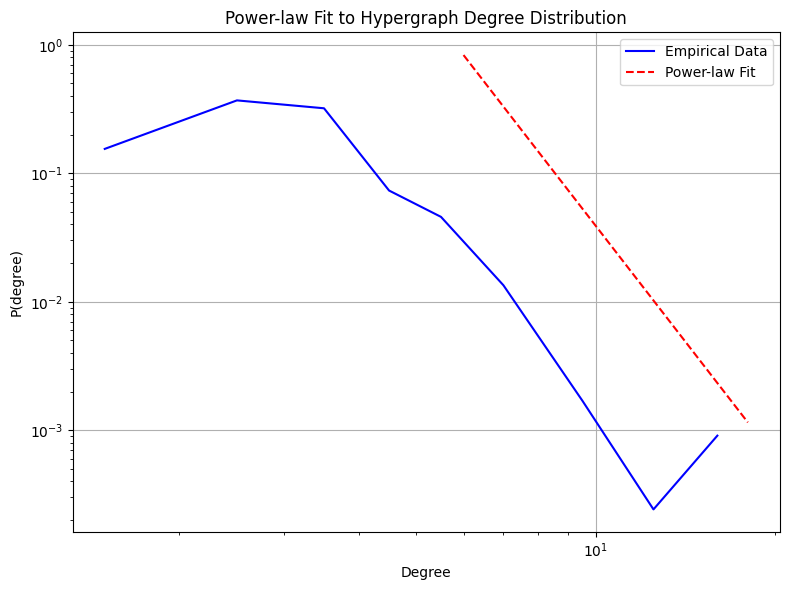

Trial 3: ❌ Does NOT follow power-law
Calculating best minimal value for power law fit
  R = 48.7388, p = 0.0000


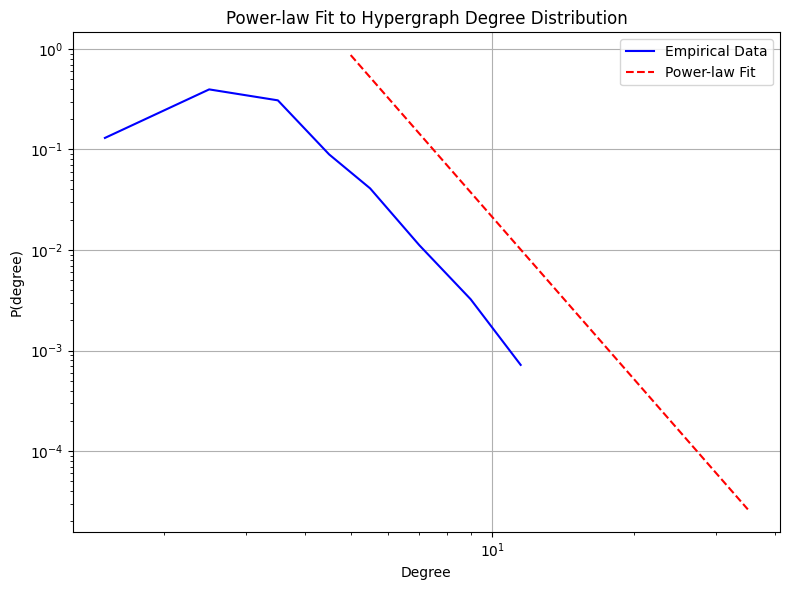

Trial 4: ❌ Does NOT follow power-law
Calculating best minimal value for power law fit
  R = 86.7172, p = 0.0000


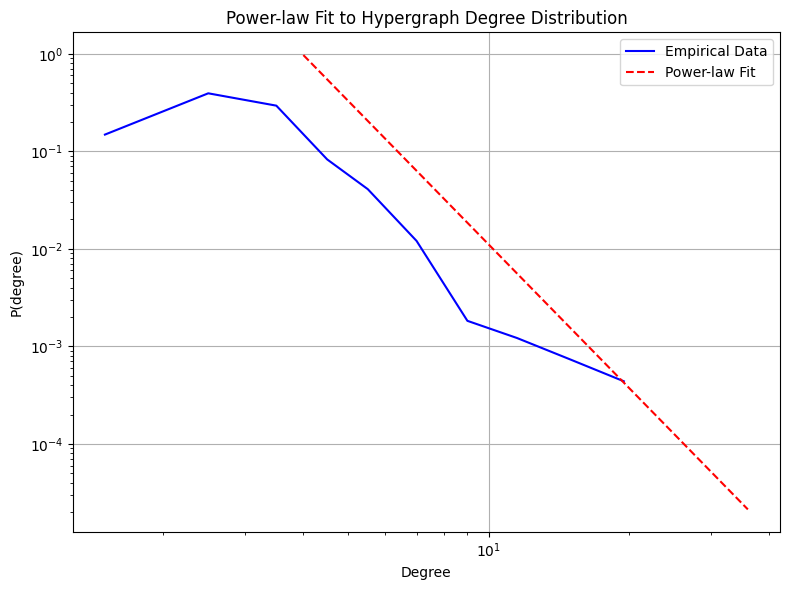

Trial 5: ❌ Does NOT follow power-law
Calculating best minimal value for power law fit
  R = 21.3800, p = 0.0000


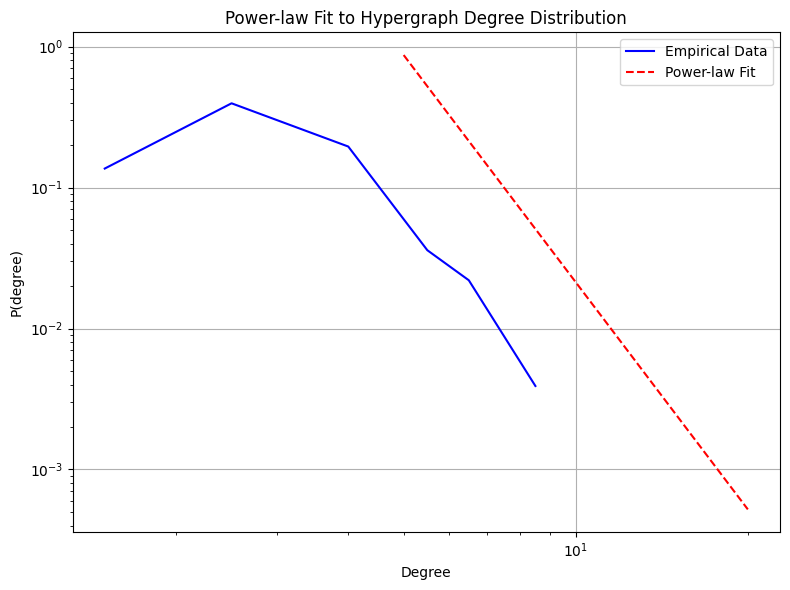

Trial 6: ❌ Does NOT follow power-law
Calculating best minimal value for power law fit
  R = 21.0663, p = 0.0000


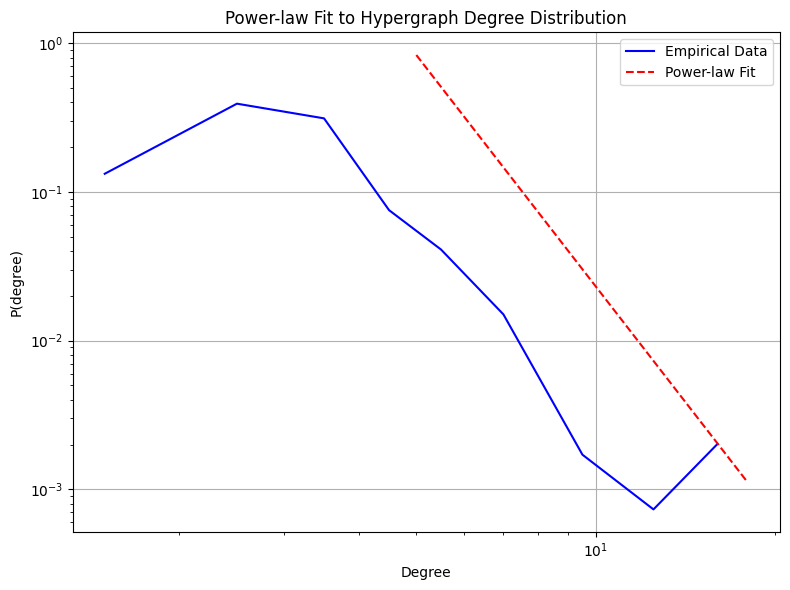

Trial 7: ❌ Does NOT follow power-law
Calculating best minimal value for power law fit
  R = 49.3312, p = 0.0000


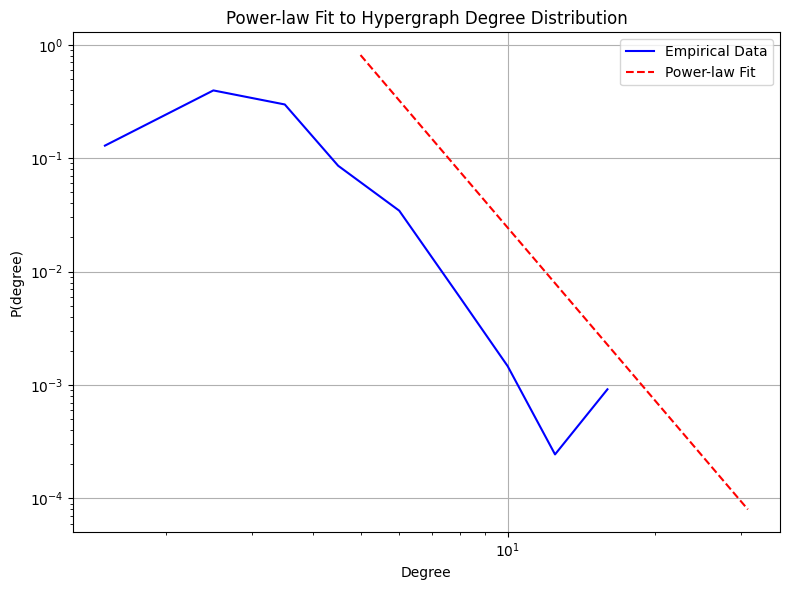

Trial 8: ❌ Does NOT follow power-law
Calculating best minimal value for power law fit
  R = 56.1902, p = 0.0000


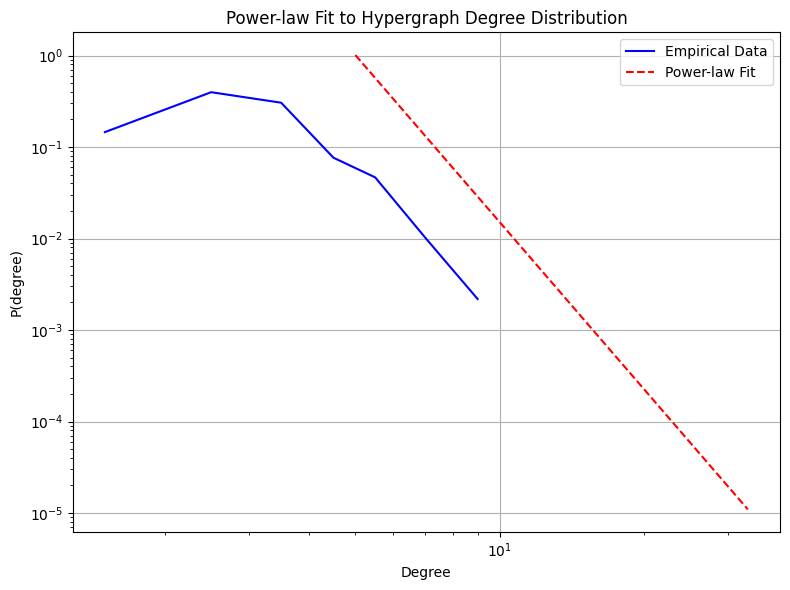

Trial 9: ❌ Does NOT follow power-law
Calculating best minimal value for power law fit
  R = 53.7171, p = 0.0000


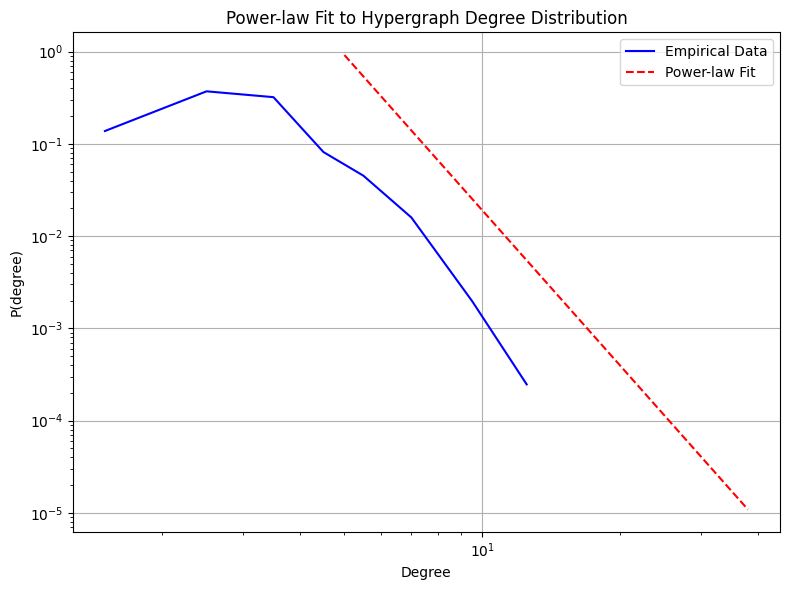

Trial 10: ❌ Does NOT follow power-law

Out of 10 trials, 0 hypergraphs followed power-law (p ≥ 0.10).


In [ ]:
from edge_rewiring import model_generation, power_law

success_count = 0
trials = 10

for i in range(trials):
    H = model_generation.model_generation_es(
        es=0.5,
        approx_num_C=700,
        num_max_hyperedge=30,
        num_node=600,
        min_size=2,
        max_size=10
    )

    # Optional: clean up isolated nodes if needed
    # H.cleanup(singletons=True)

    result = power_law.has_powerlaw(H, p_value=0.10)

    if isinstance(result, tuple):
        follows_powerlaw, fit_stats = result
    else:
        follows_powerlaw = result  # fallback if your function returns just a bool

    if follows_powerlaw:
        success_count += 1
        print(f"Trial {i+1}: ✅ Follows power-law")
    else:
        print(f"Trial {i+1}: ❌ Does NOT follow power-law")

print(f"\nOut of {trials} trials, {success_count} hypergraphs followed power-law (p ≥ 0.10).")
